In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV log generated by the gateway
csv_file = '01.csv'
df = pd.read_csv(csv_file, comment='#')

# Clean and separate robot datasets
df['time_sec'] = (df['rx_ms'] - df['rx_ms'].iloc[0]) / 1000.0

r2 = df[df['senderId'] == 2].copy()
r3 = df[df['senderId'] == 3].copy()
r4 = df[df['senderId'] == 4].copy()

print(f"Dataset summary:")
print(f"Total rows: {len(df)}")
print(f"R2 samples: {len(r2)}, R3 samples: {len(r3)}, R4 samples: {len(r4)}")
print(f"Experiment duration: {df['time_sec'].max():.2f} seconds")

Dataset summary:
Total rows: 780
R2 samples: 275, R3 samples: 257, R4 samples: 248
Experiment duration: 73.44 seconds


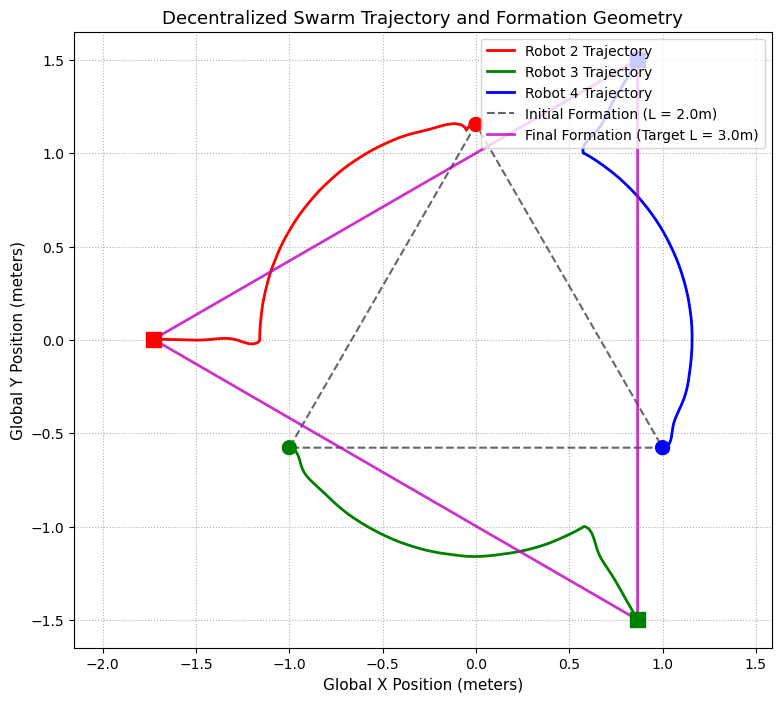

ESKF Estimated Inter-Robot Distances at Final Pose:
d(R2, R3) = 2.998 m
d(R2, R4) = 2.995 m
d(R3, R4) = 3.000 m


In [2]:
plt.figure(figsize=(9, 8))

# Plot robot trajectories
plt.plot(r2['posX'], r2['posY'], 'r-', linewidth=2, label='Robot 2 Trajectory')
plt.plot(r3['posX'], r3['posY'], 'g-', linewidth=2, label='Robot 3 Trajectory')
plt.plot(r4['posX'], r4['posY'], 'b-', linewidth=2, label='Robot 4 Trajectory')

# Initial Triangle (t = 0)
init_x = [r2['posX'].iloc[0], r3['posX'].iloc[0], r4['posX'].iloc[0], r2['posX'].iloc[0]]
init_y = [r2['posY'].iloc[0], r3['posY'].iloc[0], r4['posY'].iloc[0], r2['posY'].iloc[0]]
plt.plot(init_x, init_y, 'k--', alpha=0.6, label='Initial Formation (L = 2.0m)')
plt.scatter(init_x[:-1], init_y[:-1], c=['red', 'green', 'blue'], s=100, zorder=5)

# Final Triangle (End of maneuver)
final_x = [r2['posX'].iloc[-1], r3['posX'].iloc[-1], r4['posX'].iloc[-1], r2['posX'].iloc[-1]]
final_y = [r2['posY'].iloc[-1], r3['posY'].iloc[-1], r4['posY'].iloc[-1], r2['posY'].iloc[-1]]
plt.plot(final_x, final_y, 'm-', linewidth=2, alpha=0.8, label='Final Formation (Target L = 3.0m)')
plt.scatter(final_x[:-1], final_y[:-1], c=['red', 'green', 'blue'], marker='s', s=120, zorder=5)

plt.title('Decentralized Swarm Trajectory and Formation Geometry', fontsize=13)
plt.xlabel('Global X Position (meters)', fontsize=11)
plt.ylabel('Global Y Position (meters)', fontsize=11)
plt.grid(True, linestyle=':')
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()

# Compute final distances between estimated positions
p2 = np.array([r2['posX'].iloc[-1], r2['posY'].iloc[-1]])
p3 = np.array([r3['posX'].iloc[-1], r3['posY'].iloc[-1]])
p4 = np.array([r4['posX'].iloc[-1], r4['posY'].iloc[-1]])

d23 = np.linalg.norm(p2 - p3)
d24 = np.linalg.norm(p2 - p4)
d34 = np.linalg.norm(p3 - p4)

print(f"ESKF Estimated Inter-Robot Distances at Final Pose:")
print(f"d(R2, R3) = {d23:.3f} m")
print(f"d(R2, R4) = {d24:.3f} m")
print(f"d(R3, R4) = {d34:.3f} m")

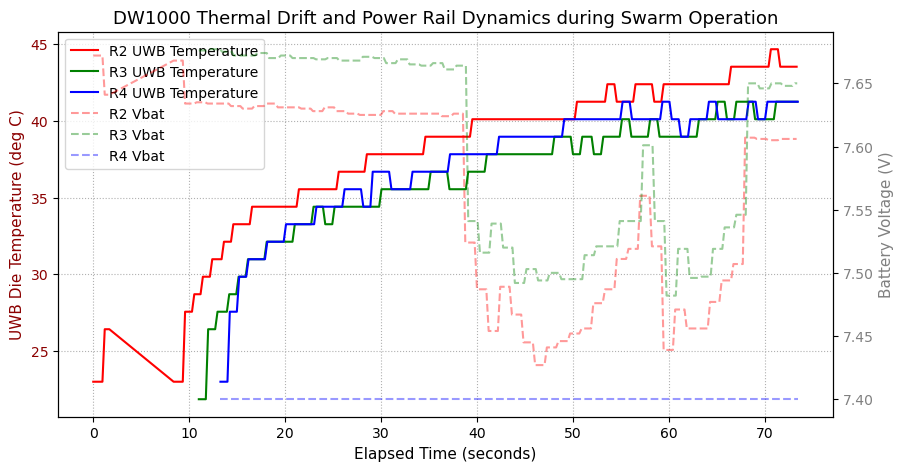

In [3]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Temperature curves
ax1.plot(r2['time_sec'], r2['senderTempUwb'], 'r-', label='R2 UWB Temperature')
ax1.plot(r3['time_sec'], r3['senderTempUwb'], 'g-', label='R3 UWB Temperature')
ax1.plot(r4['time_sec'], r4['senderTempUwb'], 'b-', label='R4 UWB Temperature')
ax1.set_xlabel('Elapsed Time (seconds)', fontsize=11)
ax1.set_ylabel('UWB Die Temperature (deg C)', color='darkred', fontsize=11)
ax1.tick_params(axis='y', labelcolor='darkred')
ax1.grid(True, linestyle=':')

# Battery voltage on twin axis
ax2 = ax1.twinx()
ax2.plot(r2['time_sec'], r2['vbat'], 'r--', alpha=0.4, label='R2 Vbat')
ax2.plot(r3['time_sec'], r3['vbat'], 'g--', alpha=0.4, label='R3 Vbat')
ax2.plot(r4['time_sec'], r4['vbat'], 'b--', alpha=0.4, label='R4 Vbat')
ax2.set_ylabel('Battery Voltage (V)', color='gray', fontsize=11)
ax2.tick_params(axis='y', labelcolor='gray')

plt.title('DW1000 Thermal Drift and Power Rail Dynamics during Swarm Operation', fontsize=13)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.show()

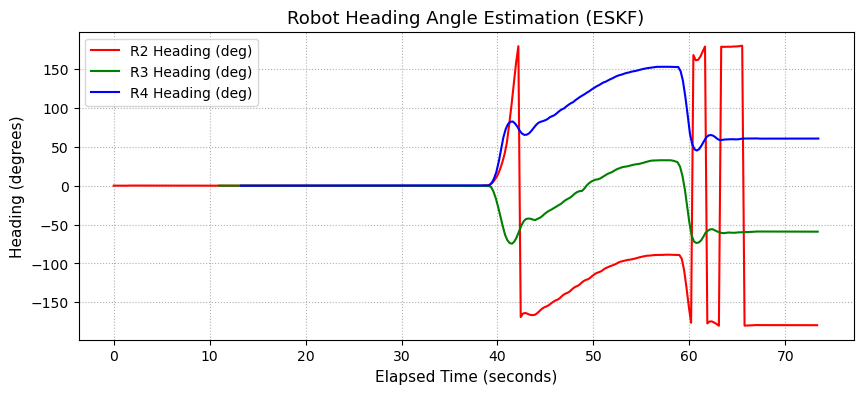

In [4]:
plt.figure(figsize=(10, 4))

plt.plot(r2['time_sec'], np.degrees(r2['headingRad']), 'r-', label='R2 Heading (deg)')
plt.plot(r3['time_sec'], np.degrees(r3['headingRad']), 'g-', label='R3 Heading (deg)')
plt.plot(r4['time_sec'], np.degrees(r4['headingRad']), 'b-', label='R4 Heading (deg)')

plt.title('Robot Heading Angle Estimation (ESKF)', fontsize=13)
plt.xlabel('Elapsed Time (seconds)', fontsize=11)
plt.ylabel('Heading (degrees)', fontsize=11)
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

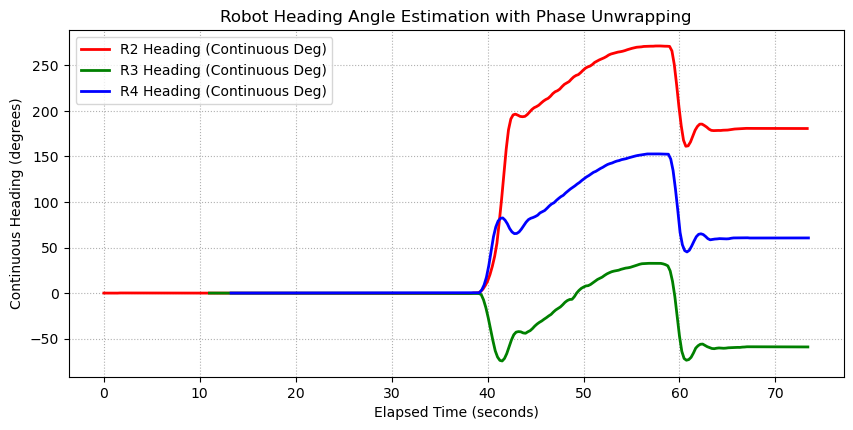

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('01.csv', comment='#')
df['time_sec'] = (df['rx_ms'] - df['rx_ms'].iloc[0]) / 1000.0

r2 = df[df['senderId'] == 2].copy()
r3 = df[df['senderId'] == 3].copy()
r4 = df[df['senderId'] == 4].copy()

# Plot Heading with Angle Unwrapping to eliminate discontinuous spikes
plt.figure(figsize=(10, 4.5))

# np.unwrap eliminates artificial 360-degree wraps around +/- pi
r2_heading_unwrapped = np.degrees(np.unwrap(r2['headingRad'].values))
r3_heading_unwrapped = np.degrees(np.unwrap(r3['headingRad'].values))
r4_heading_unwrapped = np.degrees(np.unwrap(r4['headingRad'].values))

plt.plot(r2['time_sec'], r2_heading_unwrapped, 'r-', linewidth=2, label='R2 Heading (Continuous Deg)')
plt.plot(r3['time_sec'], r3_heading_unwrapped, 'g-', linewidth=2, label='R3 Heading (Continuous Deg)')
plt.plot(r4['time_sec'], r4_heading_unwrapped, 'b-', linewidth=2, label='R4 Heading (Continuous Deg)')

plt.title('Robot Heading Angle Estimation with Phase Unwrapping', fontsize=12)
plt.xlabel('Elapsed Time (seconds)', fontsize=10)
plt.ylabel('Continuous Heading (degrees)', fontsize=10)
plt.grid(True, linestyle=':')
plt.legend(loc='upper left')
plt.show()